In [1]:
from cellpose import io, metrics
from glob import glob
import matplotlib.pyplot as plt
from natsort import natsorted
import numpy as np
import pandas as pd
import re

# Inspection of the loss function

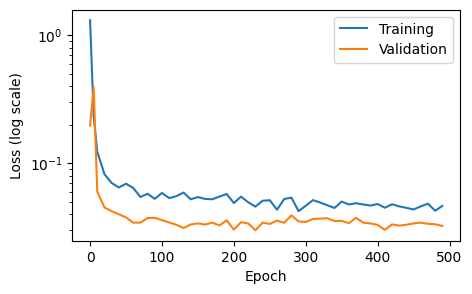

In [2]:
# Path to your log file
log_file_path = 'training_log.txt'

# Lists to store extracted data
epochs = []
train_loss = []
val_loss = []

# Regular expression to match the lines with loss values
epoch_loss_pattern = re.compile(r'Epoch (\d+), .* Loss (\d+\.\d+), Loss Test (\d+\.\d+)')

# Open and parse the log file
with open(log_file_path, 'r') as file:
    for line in file:
        match = epoch_loss_pattern.search(line)
        if match:
            epoch = int(match.group(1))
            train = float(match.group(2))
            val = float(match.group(3))
            epochs.append(epoch)
            train_loss.append(train)
            val_loss.append(val)

# Convert to dataframe
df = pd.DataFrame({
    'Epoch': epochs,
    'Train Loss': train_loss,
    'Val Loss': val_loss
})

# Plot training and validation loss over epochs
df.plot(x = 'Epoch', y = ['Train Loss', 'Val Loss'], logy=True, figsize=(5, 3))
plt.legend(['Training', 'Validation'])
plt.ylabel('Loss (log scale)')
plt.show()

# Error mapping and quality metrics estimation

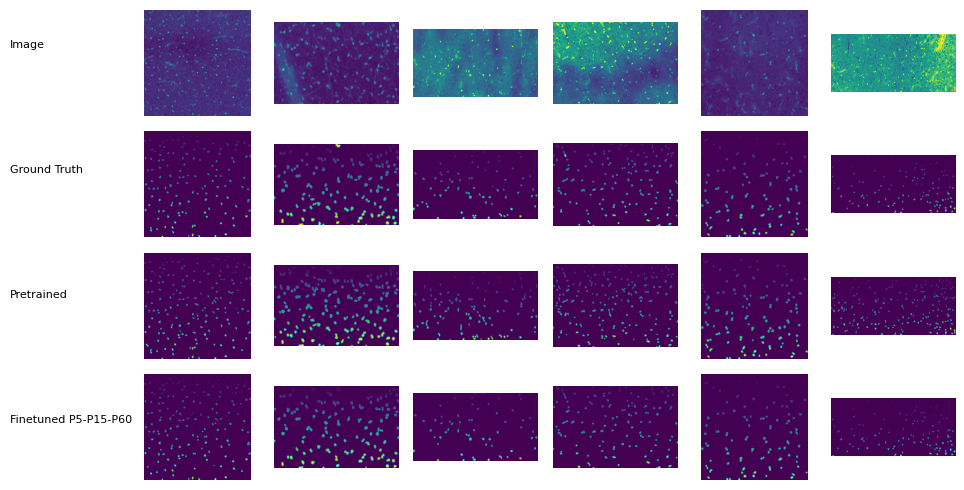

In [3]:
# Paths for raw images and associated test masks (ground truth, pretrained, finetuned)
paths = ['test_set/*.jpg',
        'test_set/gt/*.npy',
        'test_set/cyto2/*.npy',
        'test_set/cyto2_sox9_p5-15-60_27-11-24/*.npy']

# Load all image sets into a list of lists
image_sets = [[io.imread(f) for f in natsorted(glob(p))] for p in paths]
nimg = len(image_sets[0])

# Plot each image and its corresponding masks
fig = plt.figure(figsize=(10, 5), dpi=100)
for row, images in enumerate(image_sets):
    for col in range(nimg):
        ax = fig.add_subplot(4, nimg, row * nimg + col + 1)
        ax.imshow(images[col])
        ax.axis('off')
# Add row titles
titles = ['Image', 'Ground Truth', 'Pretrained', 'Finetuned P5-P15-P60']
y_positions = [0.9, 0.65, 0.4, 0.15]
for title, y in zip(titles, y_positions):
    fig.text(0.04, y, title, va='center', rotation='horizontal', fontsize=8)
# Adjust layout
plt.tight_layout(rect=[0.15, 0, 1, 1])
plt.show()

## Pretrained model: cyto2

In [4]:
aji = metrics.aggregated_jaccard_index(image_sets[1], image_sets[2]) # Aggregated jaccard index = intersection of all matched masks / union of all masks 

scales = np.arange(0.5, 1.05, 0.05)
ap, tp, fp, fn = metrics.average_precision(image_sets[1], image_sets[2], scales) # Average precision = TP / (TP + FP + FN) at each given IoU threshold

tp = tp.sum(0)
fp = fp.sum(0)
fn = fn.sum(0)

ap_pretrained = tp / (tp + fp + fn)
precision = tp / (tp + fp)
recall = tp / (tp + fn)
fscore = 2 * precision * recall / (precision + recall)

/tmp/ipykernel_122642/2514894052.py:13: RuntimeWarning: invalid value encountered in divide
  fscore = 2 * precision * recall / (precision + recall)


In [5]:
scaleId = 0
print(f"\n📊 Model evaluation at IoU threshold: {scales[scaleId]:.2f}\n")

print(f"True Positives (TP):  {tp[scaleId]:.0f}")
print(f"False Positives (FP): {fp[scaleId]:.0f}")
print(f"False Negatives (FN): {fn[scaleId]:.0f}\n")

print(f"Average Precision: {ap_pretrained[scaleId]:.3f}")
print(f"Precision:         {precision[scaleId]:.3f}")
print(f"Recall:            {recall[scaleId]:.3f}")
print(f"F1 Score:          {fscore[scaleId].mean():.3f}")


📊 Model evaluation at IoU threshold: 0.50

True Positives (TP):  716
False Positives (FP): 297
False Negatives (FN): 50

Average Precision: 0.674
Precision:         0.707
Recall:            0.935
F1 Score:          0.805


## Fine-tuned model 1: cyto2_sox9_p5-15-60_27-11-24

In [6]:
aji = metrics.aggregated_jaccard_index(image_sets[1], image_sets[3]) # Aggregated jaccard index = intersection of all matched masks / union of all masks 

scales = np.arange(0.5, 1.05, 0.05)
ap, tp, fp, fn = metrics.average_precision(image_sets[1], image_sets[3], scales) # Average precision = TP / (TP + FP + FN) at each given IoU threshold

tp = tp.sum(0)
fp = fp.sum(0)
fn = fn.sum(0)

ap_finetuned = tp / (tp + fp + fn)
precision = tp / (tp + fp)
recall = tp / (tp + fn)
fscore = 2 * precision * recall / (precision + recall)

/tmp/ipykernel_122642/3461935299.py:13: RuntimeWarning: invalid value encountered in divide
  fscore = 2 * precision * recall / (precision + recall)


In [7]:
scaleId = 0
print(f"\n📊 Model evaluation at IoU threshold: {scales[scaleId]:.2f}\n")

print(f"True Positives (TP):  {tp[scaleId]:.0f}")
print(f"False Positives (FP): {fp[scaleId]:.0f}")
print(f"False Negatives (FN): {fn[scaleId]:.0f}\n")

print(f"Average Precision:   {ap_finetuned[scaleId]:.3f}")
print(f"Precision:           {precision[scaleId]:.3f}")
print(f"Recall:              {recall[scaleId]:.3f}")
print(f"F1 Score:            {fscore[scaleId].mean():.3f}")


📊 Model evaluation at IoU threshold: 0.50

True Positives (TP):  688
False Positives (FP): 57
False Negatives (FN): 78

Average Precision:   0.836
Precision:           0.923
Recall:              0.898
F1 Score:            0.911


## Compare models

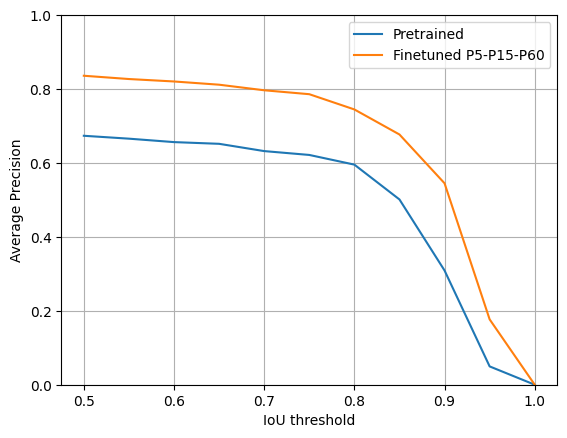

In [8]:
x = np.arange(0.5, 1.05, 0.05)
plt.plot(x, np.c_[ap_pretrained, ap_finetuned], label=['Pretrained', 'Finetuned P5-P15-P60'])
plt.xlabel("IoU threshold")
plt.ylabel("Average Precision")
plt.ylim((0,1))
plt.legend()
plt.grid()
plt.show()